In [1]:
import os
import json
import torch
import argparse
import numpy as np
import difflib
import networkx as nx
import re
import matplotlib.pyplot as plt
import sentencepiece as spm
from sklearn.metrics.pairwise import cosine_similarity
from dataset_multilingual import EurParallelDatasetBPE, collate_parallelBPE
from dataset import EurDataset, collate_data
from models.transceiver import DeepSC
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.preprocessing import normalize
import copy
from w3lib.html import remove_tags
from student import Student
from models.lora2 import (
    apply_lora_to_decoder, 
    # load_lora,
    load_language_adapter,
    load_language_adapter_auto
)
from utils import( 
    BleuScore, 
    SNR_to_noise, 
    greedy_decode, 
    SeqtoTextBPE, 
    Channels,
    PowerNormalize,
    subsequent_mask
)

from metrics.metrics_bpe import DeepSCMetrics

/home/prinako/External/WorkSpace/PGCC/DeepSC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
def text_to_indices_bpe(text, sp, token_to_idx, max_length, lang_token="<EN>"):
    text = normalize_text(text)

    content_ids = sp.encode(
        text,
        out_type=int,
        add_bos=False,
        add_eos=False,
    )

    # <START> + <LANG> + content + <END>
    max_content = max_length - 3
    if len(content_ids) > max_content:
        print(
            f"[Warning] {len(content_ids)} content tokens -> "
            f"truncated to {max_content}"
        )
        content_ids = content_ids[:max_content]

    seq = [
        token_to_idx["<START>"],
        token_to_idx[lang_token],
        *content_ids,
        token_to_idx["<END>"],
    ]

    return text, seq

#### Transmitter model only

In [4]:
def transmitter(src, model, padding_idx, device):
    src_mask = (src == padding_idx).unsqueeze(-2).float().to(device)
    enc_output = model.encoder(src, src_mask)
    channel_enc_output = model.channel_encoder(enc_output)
    return PowerNormalize(channel_enc_output)

#### Receiver model only

In [5]:
@torch.no_grad()
def receiver(
    Rx_sig,
    model,
    src,
    max_len,
    start_symbol,
    language_symbol,
    end_symbol,
    padding_idx,
    device,
):
    memory = model.channel_decoder(Rx_sig)

    outputs = torch.tensor(
        [[start_symbol, language_symbol]],
        dtype=src.dtype,
        device=device,
    ).repeat(src.size(0), 1)

    src_mask = (src == padding_idx).unsqueeze(-2).float().to(device)

    finished = torch.zeros(src.size(0), dtype=torch.bool, device=device)

    for _ in range(max_len - 2):
        trg_mask = (outputs == padding_idx).unsqueeze(-2).float().to(device)
        look_ahead = subsequent_mask(outputs.size(1)).float().to(device)
        combined_mask = torch.max(trg_mask, look_ahead)

        dec_output = model.decoder(
            outputs,
            memory,
            combined_mask,
            src_mask,
        )

        logits = model.dense(dec_output)
        next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)

        next_token = torch.where(
            finished.unsqueeze(1),
            torch.full_like(next_token, end_symbol),
            next_token,
        )

        outputs = torch.cat([outputs, next_token], dim=1)
        finished |= next_token.squeeze(1).eq(end_symbol)

        if torch.all(finished):
            break

    return outputs


#### Decoder

In [6]:
@torch.no_grad()
def student_decode(
    Rx_sig,
    model,
    src,
    max_len,
    start_symbol,
    language_symbol,
    end_symbol,
    padding_idx,
    device,
):
    memory = model.channel_decoder(Rx_sig)

    outputs = torch.tensor(
        [[start_symbol, language_symbol]],
        dtype=src.dtype,
        device=device,
    ).repeat(src.size(0), 1)

    finished = torch.zeros(src.size(0), dtype=torch.bool, device=device)

    for _ in range(max_len - 2):
        trg_mask = (outputs == padding_idx).unsqueeze(-2).float().to(device)
        look_ahead = subsequent_mask(outputs.size(1)).float().to(device)
        combined_mask = torch.max(trg_mask, look_ahead)

        dec_output = model.decoder(
            outputs,
            memory,
            combined_mask,
            None,
        )

        logits = model.dense(dec_output)
        next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)

        next_token = torch.where(
            finished.unsqueeze(1),
            torch.full_like(next_token, end_symbol),
            next_token,
        )

        outputs = torch.cat([outputs, next_token], dim=1)
        finished |= next_token.squeeze(1).eq(end_symbol)

        if torch.all(finished):
            break

    return outputs

In [7]:
def send_through_channel(tx, channel, noise_std):
    channels = Channels()

    if channel == "AWGN":
        return channels.AWGN(tx, noise_std)
    if channel == "Rayleigh":
        return channels.Rayleigh(tx, noise_std)
    if channel == "Rician":
        return channels.Rician(tx, noise_std)

    raise ValueError("Channel must be AWGN, Rayleigh or Rician")

#### Greedy decoding

In [8]:
def student_decode2(
    Rx_sig,
    model,
    src,
    max_len,
    start_symbol,
    language_symbol,
    end_symbol,
    padding_idx,
    device,
    idx_to_token=None,
    debug=False,
    top_k=10,
):
    """
    Greedy decoding for Student / LoRA receiver.

    Starts with:
        <START> <LANGUAGE>

    Example EN -> PT:
        <START> <PT>
    """

    # Decode received semantic/channel representation
    memory = model.channel_decoder(Rx_sig)

    # Initial decoder prefix:
    # <START> <LANGUAGE>
    outputs = torch.tensor(
        [[start_symbol, language_symbol]],
        dtype=src.dtype,
        device=device,
    ).repeat(src.size(0), 1)

    # We already have 2 tokens:
    # <START> and <LANGUAGE>
    for step in range(max_len - 2):
        trg_mask = (
            outputs == padding_idx
        ).unsqueeze(-2).float().to(device)

        # create the decode mask
        look_ahead_mask = subsequent_mask(
            outputs.size(1)
        ).float().to(device)

        combined_mask = torch.max(
            trg_mask,
            look_ahead_mask,
        )

        # decode the received signal
        dec_output = model.decoder(
            outputs,
            memory,
            combined_mask,
            None,
        )

        # [B, T, vocab]
        logits = model.dense(dec_output)

        # Only use prediction from final position
        next_logits = logits[:, -1, :]

        if debug and idx_to_token is not None:

            probs = torch.softmax(
                next_logits,
                dim=-1,
            )

            k = min(top_k, probs.size(-1))

            top_probs, top_ids = torch.topk(
                probs[0],
                k=k,
            )

            current_tokens = [
                idx_to_token.get(
                    int(token_id),
                    "<UNKNOWN>",
                )
                for token_id in outputs[0].tolist()
            ]

            print(
                f"\nStep {step + 1}"
            )

            print(
                "Current:",
                current_tokens,
            )

            print("Top predictions:")

            for token_id, probability in zip(
                top_ids.tolist(),
                top_probs.tolist(),
            ):
                token = idx_to_token.get(
                    int(token_id),
                    "<UNKNOWN>",
                )

                marker = ""

                if token_id == end_symbol:
                    marker = " <-- END"

                print(
                    f"  {token:20s}"
                    f"{probability:.6f}"
                    f"{marker}"
                )

        next_word = next_logits.argmax(
            dim=-1,
            keepdim=True,
        )

        outputs = torch.cat(
            [outputs, next_word],
            dim=1,
        )

        # Stop if every sequence generated <END>
        if torch.all(
            next_word.squeeze(1) == end_symbol
        ):
            break

    return outputs

#### Beam search decoding

In [9]:
def student_beam_decode(
    Rx_sig,
    model,
    src,
    max_len,
    start_symbol,
    language_symbol,
    end_symbol,
    padding_idx,
    device,
    beam_size=5,
    length_penalty=0.7,
    idx_to_token=None,
    debug=False,
):
    """
    Beam-search decoding for Student / LoRA receiver.

    Prefix:
        <START> <LANGUAGE>

    Example EN -> PT:
        <START> <PT>

    Parameters
    ----------
    beam_size : int
        Number of candidate sequences retained at each step.

    length_penalty : float
        Penalizes overly short sequences.
        0.0 = no length normalization.
        Typical values: 0.6 - 1.0.

    debug : bool
        Print current beam candidates.
    """

    model.eval()

    with torch.no_grad():

        # Channel decoding
        memory = model.channel_decoder(Rx_sig)

        batch_size = src.size(0)

        if batch_size != 1:
            raise ValueError(
                "This beam-search implementation currently "
                "supports batch_size=1."
            )

        # Initial prefix:
        # <START> <LANGUAGE>
        initial_sequence = torch.tensor(
            [[start_symbol, language_symbol]],
            dtype=src.dtype,
            device=device,
        )

        # Each beam:
        # {
        #   "tokens": Tensor [1, T],
        #   "score": cumulative log probability,
        #   "finished": bool
        # }
        beams = [
            {
                "tokens": initial_sequence,
                "score": 0.0,
                "finished": False,
            }
        ]

        # Length-normalized score
        def normalized_score(beam):
            tokens = beam["tokens"]

            # Ignore <START> and language token
            generated_length = max(
                tokens.size(1) - 2,
                1,
            )

            if length_penalty <= 0:
                return beam["score"]

            penalty = (
                (5.0 + generated_length) / 6.0
            ) ** length_penalty

            return beam["score"] / penalty

        # Beam-search loop
        for step in range(max_len - 2):

            candidates = []

            for beam in beams:

                # Finished beams are kept as-is
                if beam["finished"]:
                    candidates.append(beam)
                    continue

                outputs = beam["tokens"]

                # Target padding mask
                trg_mask = (
                    outputs == padding_idx
                ).unsqueeze(-2).float().to(device)

                # Causal mask
                look_ahead_mask = subsequent_mask(
                    outputs.size(1)
                ).float().to(device)

                combined_mask = torch.max(
                    trg_mask,
                    look_ahead_mask,
                )

                # Decoder
                dec_output = model.decoder(
                    outputs,
                    memory,
                    combined_mask,
                    None,
                )

                logits = model.dense(dec_output)

                # Only final position matters
                next_logits = logits[:, -1, :]

                log_probs = torch.log_softmax(
                    next_logits,
                    dim=-1,
                )

                # Top-K next tokens
                top_log_probs, top_ids = torch.topk(
                    log_probs[0],
                    k=beam_size,
                )

                for log_prob, token_id in zip(
                    top_log_probs.tolist(),
                    top_ids.tolist(),
                ):

                    next_token = torch.tensor(
                        [[token_id]],
                        dtype=src.dtype,
                        device=device,
                    )

                    new_tokens = torch.cat(
                        [
                            outputs,
                            next_token,
                        ],
                        dim=1,
                    )

                    candidates.append(
                        {
                            "tokens": new_tokens,
                            "score": (
                                beam["score"]
                                + float(log_prob)
                            ),
                            "finished": (
                                token_id == end_symbol
                            ),
                        }
                    )

            # Rank candidates
            candidates.sort(
                key=normalized_score,
                reverse=True,
            )

            beams = candidates[:beam_size]

            # Optional debugging
            if debug:

                print(
                    f"\n{'=' * 60}"
                )
                print(
                    f"Beam step {step + 1}"
                )
                print(
                    f"{'=' * 60}"
                )

                for rank, beam in enumerate(
                    beams,
                    start=1,
                ):

                    tokens = (
                        beam["tokens"][0]
                        .detach()
                        .cpu()
                        .tolist()
                    )

                    if idx_to_token is not None:
                        words = [
                            idx_to_token.get(
                                int(token),
                                "<UNKNOWN>",
                            )
                            for token in tokens
                        ]

                        text = " ".join(words)

                    else:
                        text = str(tokens)

                    print(
                        f"{rank:2d}. "
                        f"score={beam['score']:.4f} "
                        f"norm={normalized_score(beam):.4f} "
                        f"finished={beam['finished']}"
                    )

                    print(
                        f"    {text}"
                    )

            # Stop when all beams finished
            if all(
                beam["finished"]
                for beam in beams
            ):
                break

        # Choose best beam
        finished_beams = [
            beam
            for beam in beams
            if beam["finished"]
        ]

        if finished_beams:
            best_beam = max(
                finished_beams,
                key=normalized_score,
            )
        else:
            best_beam = max(
                beams,
                key=normalized_score,
            )

        return best_beam["tokens"]

#### Text Normalization

In [10]:

def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"([.!?,;:])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


#### Interactive Demo 1 (DeepSC)

In [11]:
def show_sequence(name, ids, sp, pad_idx):
    ids = [int(x) for x in ids if int(x) != pad_idx]
    pieces = [sp.id_to_piece(x) for x in ids]
    print("\n" + name)
    print("IDs    :", ids)
    print("Pieces :", pieces)

In [12]:
@torch.no_grad()
def interactive_demo(
    args, 
    net, 
    students, 
    text, 
    token_to_idx, 
    sp, 
    decoder, 
    device,
    snr,
    student_languages=None,
):
    print("\n" + "=" * 70)
    print("DeepSC BPE interactive mode")
    print("=" * 70)

    pad_idx = token_to_idx["<PAD>"]
    start_idx = token_to_idx["<START>"]
    end_idx = token_to_idx["<END>"]


    # Validate models/languages
    if student_languages is None:
        student_languages = ["<EN>"] * len(students)

    if len(student_languages) != len(students):
        raise ValueError(
            "student_languages must contain one language "
            "for each student model."
        )

    for language in student_languages:
        if language not in token_to_idx:
            raise ValueError(
                f"Language token {language!r} not found in vocabulary."
            )

    normalized, seq = text_to_indices_bpe(
        text,
        sp,
        token_to_idx,
        args.MAX_LENGTH,
        "<EN>",
    )

    src = torch.tensor([seq], dtype=torch.long, device=device)

    show_sequence("INPUT BPE", seq, sp, pad_idx)
    print("Decoded input:", decoder.sequence_to_text(seq))
    print("Input length :", len(seq))

    net.eval()
    for student in students:
        if student is not None:
            student.eval()

    tx_sig = transmitter(src, net, pad_idx, device)
    print("\nTransmitting ...")
    print("Tx shape:", tuple(tx_sig.shape))

    noise_std = SNR_to_noise(snr)
    rx_sig = send_through_channel(tx_sig, args.channel, noise_std)

    teacher_out = receiver(
        rx_sig,
        net,
        src,
        args.MAX_LENGTH,
        start_idx,
        token_to_idx["<EN>"],
        end_idx,
        pad_idx,
        device,
    )

    students_out = []
    student_pt_out = None


    for student, language in zip(students, student_languages):
        if student is not None:
            student_out = student_decode(
                rx_sig,
                student,
                src,
                args.MAX_LENGTH,
                start_idx,
                token_to_idx[language],
                end_idx,
                pad_idx,
                device,
            )

            students_out.append(student_out)

    # if students[0] is not None:
    #     student_en_out = student_decode(
    #         rx_sig,
    #         students[0],
    #         src,
    #         args.MAX_LENGTH,
    #         start_idx,
    #         token_to_idx["<EN>"],
    #         end_idx,
    #         pad_idx,
    #         device,
    #     )

    # if students[1] is not None:
    #     student_pt_out = student_decode(
    #         rx_sig,
    #         students[1],
    #         src,
    #         args.MAX_LENGTH,
    #         start_idx,
    #         token_to_idx["<EN>"],
    #         end_idx,
    #         pad_idx,
    #         device,
    #     )

    teacher_ids = teacher_out[0].cpu().tolist()
    teacher_text = decoder.sequence_to_text(teacher_ids)
    # show_sequence("TEACHER EN BPE", teacher_ids, sp, pad_idx)

    students_text = []
    # student_pt_text = None

    for student, lan in zip(students_out, student_languages):
        ids = student[0].cpu().tolist()
        text = decoder.sequence_to_text(ids)
        students_text.append(text)
        # show_sequence(f"STUDENT {lan} BPE", ids, sp, pad_idx)

    # if student_en_out is not None:
    #     ids = student_en_out[0].cpu().tolist()
    #     student_en_text = decoder.sequence_to_text(ids)
    #     show_sequence("STUDENT EN BPE", ids, sp, pad_idx)

    # if student_pt_out is not None:
    #     ids = student_pt_out[0].cpu().tolist()
    #     student_pt_text = decoder.sequence_to_text(ids)
    #     show_sequence("STUDENT / LoRA PT BPE", ids, sp, pad_idx)

    print("\n" + "-" * 70)
    print("Original EN          :", normalized)
    print("Received Teacher EN  :", teacher_text)
    for student_text, language in zip(students_text, student_languages):
        print(f"Received Student {language}:", student_text)
    
    # if student_en_text is not None:
    #     print("Student EN Received :", student_en_text)
    # if student_pt_text is not None:
    #     print("LoRA / Student PT   :", student_pt_text)
    print("-" * 70)

    return normalized, teacher_text, students_text

#### Interactive Demo 2 (DeepSC)

In [13]:
def interactive_demo2(
    args,
    net,
    students,
    tokenizer_model,
    text,
    token_to_idx,
    start_idx,
    end_idx,
    pad_idx,
    device,
    snr_in=6.0,
    student_languages=None,
    debug_tokens=False,
):
    """
    Interactive DeepSC inference.

    Parameters
    ----------
    args :
        Configuration namespace. Must contain:
            args.channel
            args.MAX_LENGTH

    net :
        Teacher / base DeepSC model.

    students : list
        List of student or LoRA models.

    text : str
        Input sentence.

    token_to_idx : dict
        Vocabulary token -> index mapping.

    start_idx : int
        <START> token index.

    end_idx : int
        <END> token index.

    pad_idx : int
        <PAD> token index.

    device :
        torch device.

    snr_in : float
        SNR in dB.

    student_languages : list[str], optional
        Target language token for each student.

        Example:
            ["<EN>", "<PT>"]

        means:
            students[0] -> English
            students[1] -> Portuguese

    debug_tokens : bool
        Print raw generated token IDs/tokens.
    """

    print("\n" + "=" * 70)
    print("DeepSC Interactive Mode")
    print("=" * 70)

    # Validate models/languages
    if student_languages is None:
        student_languages = ["<EN>"] * len(students)

    if len(student_languages) != len(students):
        raise ValueError(
            "student_languages must contain one language "
            "for each student model."
        )

    for language in student_languages:
        if language not in token_to_idx:
            raise ValueError(
                f"Language token {language!r} not found in vocabulary."
            )

    # Initialize tokenizer
    sp = spm.SentencePieceProcessor(
        model_file=tokenizer_model
    )


    seq_to_text = SeqtoTextBPE(
        token_to_idx,
        end_idx,
        tokenizer_model=tokenizer_model,
    )

    idx_to_token = {
        idx: token
        for token, idx in token_to_idx.items()
    }
    
    # Normalize input
    text = normalize_text(
        text.lower().strip()
    )

    # SNR
    try:
        snr = float(snr_in)
    except (ValueError, TypeError):
        snr = 6.0

    noise_std = SNR_to_noise(snr)
    channels = Channels()

    print(f"Channel : {args.channel}")
    print(f"SNR     : {snr:.2f} dB")

    # Convert input sentence to token IDs
    seq = text_to_indices(
        text=text,
        token_to_idx=token_to_idx,
        start_idx=start_idx,
        end_idx=end_idx,
        pad_idx=pad_idx,
        max_length=args.MAX_LENGTH,
    )

    src = torch.tensor(
        [seq],
        dtype=torch.long,
        device=device,
    )

    # Evaluation mode
    net.eval()

    for student in students:
        student.eval()

    # Transmission
    with torch.no_grad():

        Tx_sig = transmitter(
            src=src,
            model=net,
            padding_idx=pad_idx,
            device=device,
        )

        print("\nTransmitting ...")
        print("Tx shape:", Tx_sig.shape)

        # Channel
        if args.channel == "AWGN":

            Rx_sig = channels.AWGN(
                Tx_sig,
                noise_std,
            )

        elif args.channel == "Rayleigh":

            Rx_sig = channels.Rayleigh(
                Tx_sig,
                noise_std,
            )

        elif args.channel == "Rician":

            Rx_sig = channels.Rician(
                Tx_sig,
                noise_std,
            )

        else:
            raise ValueError(
                f"Unsupported channel: {args.channel}. "
                "Choose AWGN, Rayleigh, or Rician."
            )

        # Teacher
        #
        # Teacher reconstruction language = English
        teacher_out = receiver(
            Rx_sig=Rx_sig,
            model=net,
            src=src,
            max_len=args.MAX_LENGTH,
            start_symbol=start_idx,
            padding_idx=pad_idx,
            language_symbol=token_to_idx["<EN>"],
            end_symbol=end_idx,
            device=device,
        )

        # Students / LoRA adapters
        student_outputs = []
        
        lora_pt_beam = None

        for student_model, language in zip(
            students,
            student_languages,
        ):
            output = student_decode2(
                Rx_sig=Rx_sig,
                model=student_model,
                src=src,
                max_len=args.MAX_LENGTH,
                start_symbol=start_idx,
                language_symbol=token_to_idx[language],
                end_symbol=end_idx,
                padding_idx=pad_idx,
                device=device,
                idx_to_token=idx_to_token,
                debug= False,
                top_k= None if language == "<EN>" else 10,
            )
            if language == "<PT>":
                lora_pt_beam = student_beam_decode(
                    Rx_sig=Rx_sig,
                    model=student_model,
                    src=src,
                    max_len=args.MAX_LENGTH,
                    start_symbol=start_idx,
                    language_symbol=token_to_idx[language],
                    end_symbol=end_idx,
                    padding_idx=pad_idx,
                    device=device,
                    beam_size=5,
                    length_penalty=0.7,
                    idx_to_token=idx_to_token,
                    debug=False,
                )

            student_outputs.append(output)
       


    # Helper: tensor -> IDs -> text
    def decode_output(output):
        ids = output.detach().cpu().tolist()[0]

        decoded = seq_to_text.sequence_to_text(ids)

        decoded = (
            decoded
            .replace(" ,", ",")
            .replace(" .", ".")
            .replace(" !", "!")
            .replace(" ?", "?")
            .replace(" ;", ";")
            .replace(" :", ":")
        )

        return ids, decoded

    # Decode teacher
    teacher_ids, teacher_text = decode_output(
        teacher_out
    )

    # Decode students
    decoded_students = []

    for output in student_outputs:
        ids, decoded = decode_output(output)

        decoded_students.append(
            {
                "ids": ids,
                "text": decoded,
            }
        )

    # Clean original text
    original_text = (
        text
        .replace(" ,", ",")
        .replace(" .", ".")
        .replace(" !", "!")
        .replace(" ?", "?")
        .replace(" ;", ";")
        .replace(" :", ":")
    )

    # Debug raw tokens
    if debug_tokens:

        print("\n" + "-" * 70)
        print("RAW TOKEN DEBUG")
        print("-" * 70)

        print("\nInput IDs:")
        print(src[0].detach().cpu().tolist())

        print("\nInput tokens:")
        print([
            idx_to_token.get(int(idx), "<UNKNOWN>")
            for idx in src[0].detach().cpu().tolist()
        ])

        print("\nTeacher IDs:")
        print(teacher_ids)

        print("\nTeacher tokens:")
        print([
            idx_to_token.get(int(idx), "<UNKNOWN>")
            for idx in teacher_ids
        ])

        for i, result in enumerate(decoded_students):

            language = student_languages[i]

            print(
                f"\nStudent {i + 1} "
                f"target={language} IDs:"
            )
            print(result["ids"])

            print(
                f"Student {i + 1} "
                f"target={language} tokens:"
            )
            print([
                idx_to_token.get(
                    int(idx),
                    "<UNKNOWN>",
                )
                for idx in result["ids"]
            ])

    # Display results
    print("\nReceiving ...")
    print("-" * 70)

    print(
        f"{'Original EN':22s}: "
        f"{original_text}"
    )

    print(
        f"{'Teacher EN':22s}: "
        f"{teacher_text}"
    )

    for i, result in enumerate(decoded_students):

        language = student_languages[i]

        label = (
            f"Student {i + 1} "
            f"{language}"
        )

        print(
            f"{label:22s}: "
            f"{result['text']}"
        )

    print("-" * 70)

    
    greedy_ids = student_outputs[1][0].cpu().tolist()
    beam_ids = lora_pt_beam[0].cpu().tolist()

    greedy_text = seq_to_text.sequence_to_text(
        greedy_ids
    )

    beam_text = seq_to_text.sequence_to_text(
        beam_ids
    )

    greedy_text = (
        greedy_text
        .replace(" ,", ",")
        .replace(" .", ".")
    )

    beam_text = (
        beam_text
        .replace(" ,", ",")
        .replace(" .", ".")
    )

    print("\nLoRA PT Greedy :", greedy_text)
    print("LoRA PT Beam   :", beam_text)
    
    # Return structured results
    return {
        "original": original_text,

        "teacher": {
            "language": "<EN>",
            "text": teacher_text,
            "ids": teacher_ids,
        },

        "students": [
            {
                "student": i + 1,
                "language": student_languages[i],
                "text": result["text"],
                "ids": result["ids"],
            }
            for i, result in enumerate(decoded_students)
        ],

        "snr_db": snr,
        "channel": args.channel,
    }

### Main function loading models

In [14]:
def load_bpe(vocab_path, tokenizer_path):
    with open(vocab_path, "r", encoding="utf-8") as f:
        vocab = json.load(f)

    token_to_idx = vocab["token_to_idx"]
    sp = spm.SentencePieceProcessor(model_file=tokenizer_path)

    expected = {
        "<PAD>": 0,
        "<START>": 1,
        "<END>": 2,
        "<UNK>": 3,
        "<EN>": 4,
        "<PT>": 5,
        "<ES>": 6,
        "<FR>": 7,
    }

    print("=" * 70)
    print("BPE CHECK")
    print("=" * 70)
    print("SentencePiece vocab :", sp.get_piece_size())
    print("JSON vocab          :", len(token_to_idx))

    if sp.get_piece_size() != len(token_to_idx):
        raise ValueError("SentencePiece and JSON vocabulary sizes differ.")

    for token, expected_id in expected.items():
        json_id = token_to_idx[token]
        sp_id = sp.piece_to_id(token)
        print(f"{token:<8} JSON={json_id:<5} SP={sp_id:<5}")
        if json_id != expected_id or sp_id != expected_id:
            raise ValueError(f"Wrong ID for {token}")

    return token_to_idx, sp

In [15]:
def build_teacher(args, vocab_size, device):
    return DeepSC(
        args.num_layers,
        vocab_size,
        vocab_size,
        vocab_size,
        vocab_size,
        args.d_model,
        args.num_heads,
        args.dff,
        args.dropout,
    ).to(device)


In [16]:
def load_teacher(model, encoder_path, decoder_path, device):
    enc = torch.load(encoder_path, map_location=device, weights_only=False)
    dec = torch.load(decoder_path, map_location=device, weights_only=False)

    model.encoder.load_state_dict(enc["encoder"])
    model.channel_encoder.load_state_dict(enc["channel_encoder"])
    model.channel_decoder.load_state_dict(dec["channel_decoder"])
    model.decoder.load_state_dict(dec["decoder"])
    model.dense.load_state_dict(dec["dense"])

    print("Teacher loaded")
    return model

In [17]:
def build_student(args, vocab_size, device):
    return Student(
        2,
        vocab_size,
        vocab_size,
        vocab_size,
        vocab_size,
        args.d_model,
        4,
        args.dff,
        args.dropout,
    ).to(device)

In [18]:
def load_student(student, checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if all(k in ckpt for k in ("channel_decoder", "decoder", "dense")):
        student.channel_decoder.load_state_dict(ckpt["channel_decoder"])
        student.decoder.load_state_dict(ckpt["decoder"])
        student.dense.load_state_dict(ckpt["dense"])
    else:
        state = ckpt.get("model_state_dict", ckpt)
        student.load_state_dict(state)

    print("Student loaded:", checkpoint_path)
    return student


In [19]:
from types import SimpleNamespace

args = {
    "vocab_file": "data/train/europarl_bpe/vocab_bpe.json",  # vocab-file",
    "tokenizer_model": "data/train/europarl_bpe/tokenizer_bpe.model",  # tokenizer-model",
    "teacher_encoder": "results/base_model/2026-08-23/encoder_18.pth",  # teacher-encoder",
    "teacher_decoder": "results/base_model/2026-08-23/decoder_18.pth",  # teacher-decoder",
    "student_en": "results/student/2026-08-24/student_03.pth",  # student-en",
    "student_pt": "results/student/2026-08-12/student_03.pth",  # student-pt",
    "lora_adapter": "results/lora/en_pt/2026-08-31/student_adapter_en_pt_best_41.pth",  # lora-adapter",
    "channel": "Rayleigh",  # channel",
    "snr": 8,  # snr",
    "MAX_LENGTH": 51,  # MAX-LENGTH",
    "d_model": 128,  # d-model",
    "dff": 512,  # dff",
    "num_layers": 4,  # num-layers",
    "num_heads": 8,  # num-heads",
    "dropout": 0.1,  # dropout",
    "use_lora": False,  # use-lora",
    "lora_r": 8,  # lora-r",
    "lora_alpha": 16.0,  # lora-alpha",
    "lora_dropout": 0.05,  # lora-dropout",
    "lora_targets": "self_q,self_v,src_q,src_v",  # lora-targets",
}

args = SimpleNamespace(**args)


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

token_to_idx, sp = load_bpe(args.vocab_file, args.tokenizer_model)
vocab_size = len(token_to_idx)

if vocab_size != 32000:
    print("[Warning] vocab size is", vocab_size, "instead of 32000")

decoder = SeqtoTextBPE(
    token_to_idx,
    token_to_idx["<END>"],
    tokenizer_model=args.tokenizer_model,
)

teacher = build_teacher(args, vocab_size, device)

if args.teacher_encoder and args.teacher_decoder:
    teacher = load_teacher(
        teacher,
        args.teacher_encoder,
        args.teacher_decoder,
        device,
    )
else:
    print("[Warning] Teacher checkpoint not supplied; random weights are being used.")


student_en = build_student(args, vocab_size, device)
student_en = load_student(student_en, args.student_en, device)


student_pt = copy.deepcopy(student_en)
# student_pt = load_student(student_en, args.student_en, device)
# if args.use_lora:
#     if apply_lora_to_decoder is None:
#         raise ImportError("Could not import apply_lora_to_decoder from models.lora2")

#     student_pt = apply_lora_to_decoder(
#         student_pt,
#         r=args.lora_r,
#         alpha=args.lora_alpha,
#         dropout=args.lora_dropout,
#         target_modules=tuple(args.lora_targets.split(",")),
#         verbose=True,
#     )

if args.lora_adapter:
    student_pt = load_language_adapter_auto(
        student_pt,
        args.lora_adapter,
        device,
        apply_lora_fn=apply_lora_to_decoder,
    ).to(device)


Device: cuda:0
BPE CHECK
SentencePiece vocab : 32000
JSON vocab          : 32000
<PAD>    JSON=0     SP=0    
<START>  JSON=1     SP=1    
<END>    JSON=2     SP=2    
<UNK>    JSON=3     SP=3    
<EN>     JSON=4     SP=4    
<PT>     JSON=5     SP=5    
<ES>     JSON=6     SP=6    
<FR>     JSON=7     SP=7    
Teacher loaded
Student loaded: results/student/2026-08-24/student_03.pth

LoRA applied to DeepSC decoder
Rank (r)          : 8
Alpha             : 16.0
Scaling           : 2.0000
Dropout           : 0.0
Injected modules  : 20
Trainable params  : 53,248 / 8,940,544 (0.5956%)


Language Adapter Loaded
Checkpoint       : results/lora/en_pt/2026-08-31/student_adapter_en_pt_best_41.pth
Adapter name     : en_pt_best
Training epoch   : 41

LoRA configuration
  Rank           : 8
  Alpha          : 16.0
  Scaling        : 2.0000
  Dropout        : 0.0
  Targets        : ['self_q', 'self_k', 'self_v', 'self_out', 'src_q', 'src_k', 'src_v', 'src_out', 'ffn_1', 'ffn_2']

Adapter parameters

### Embeddings Visualization of Student

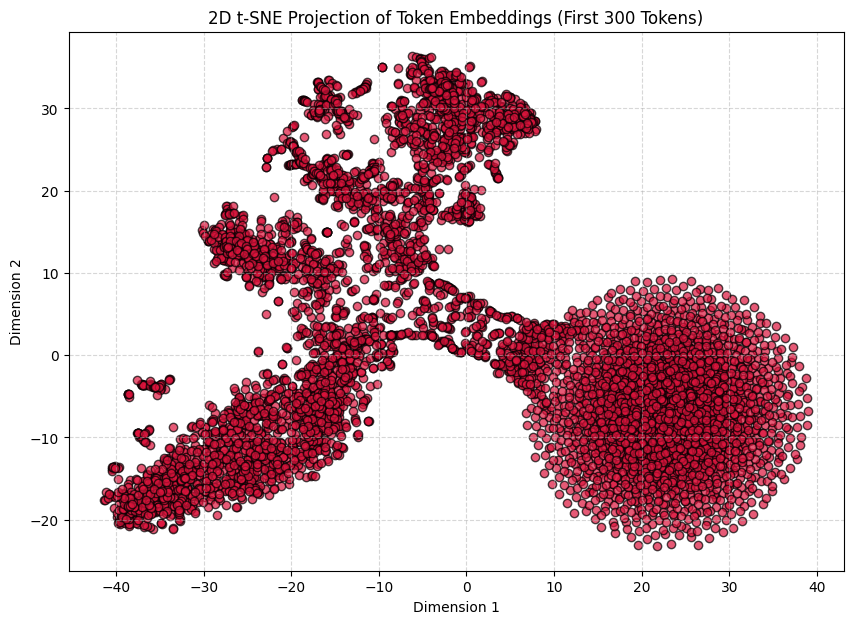

In [20]:
import matplotlib.pyplot as plt

# Optional: pip install scikit-learn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Take a sample of embeddings (e.g., 300 tokens) to reduce compute time
num_samples = 6327
embedding_matrix = student_pt.decoder.embedding.weight.data
sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# 2. Reduce 128 dimensions down to 2 dimensions using t-SNE (or PCA)
# For PCA: reducer = PCA(n_components=2)
reducer = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = reducer.fit_transform(sample_weights)

# 3. Plot the 2D projection
plt.figure(figsize=(10, 7))
plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, c="crimson", edgecolors="k"
)

plt.title("2D t-SNE Projection of Token Embeddings (First 300 Tokens)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
# plt.savefig("embedding_tsne.png", dpi=300)
plt.show()

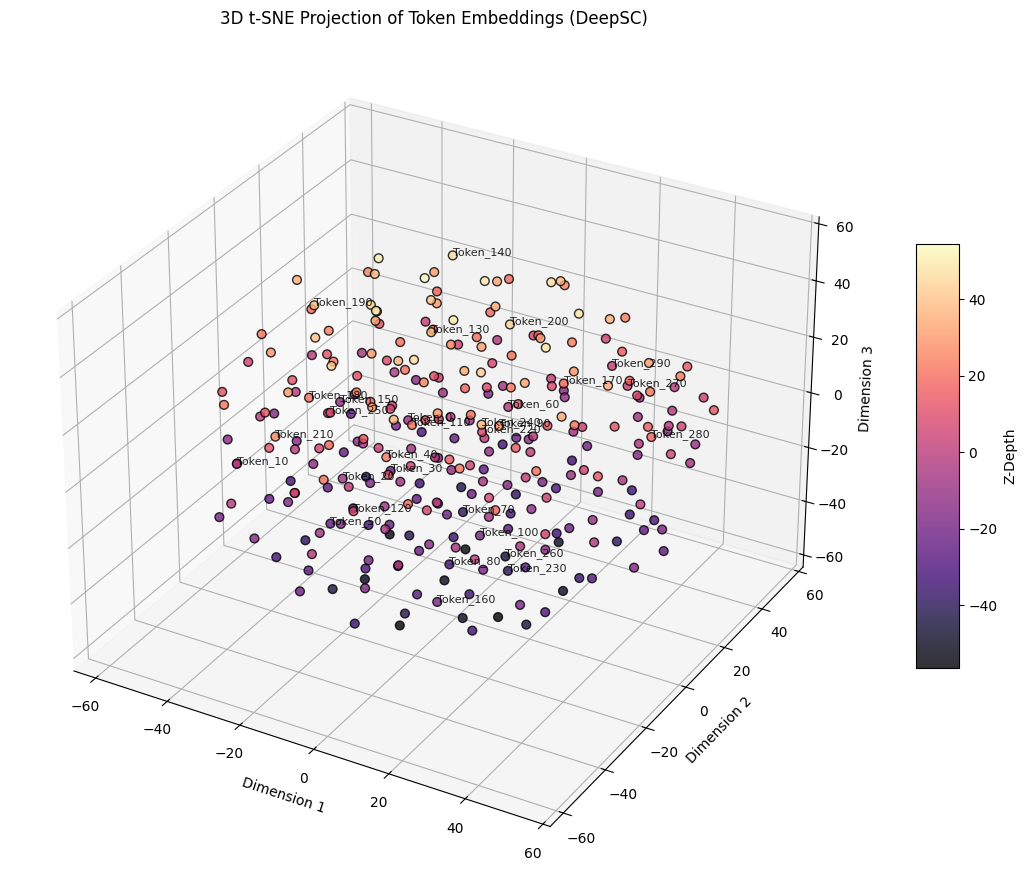

In [21]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Extract Embeddings & Map Vocab
# ---------------------------------------------------------
embedding_matrix = student_pt.decoder.embedding.weight.data
num_samples = 300
sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# Map token IDs to vocabulary words
labels = [
    id_to_word.get(i, f"T_{i}") if "id_to_word" in locals() else f"Token_{i}"
    for i in range(num_samples)
]

# ---------------------------------------------------------
# 2. Reduce Dimensions (128D -> 3D)
# ---------------------------------------------------------
from sklearn.manifold import TSNE

reducer = TSNE(n_components=3, perplexity=30, random_state=42, init="pca")
embeddings_3d = reducer.fit_transform(sample_weights)

# ---------------------------------------------------------
# 3. Plot in 3D using Matplotlib
# ---------------------------------------------------------
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Scatter points
sc = ax.scatter(
    embeddings_3d[:, 0],
    embeddings_3d[:, 1],
    embeddings_3d[:, 2],
    c=embeddings_3d[:, 2],  # Color by Z-axis depth
    cmap="magma",
    alpha=0.8,
    edgecolors="k",
    s=40,
)

# Annotate a subset of points (e.g., every 10th token to avoid clutter)
for i in range(0, num_samples, 10):
    ax.text(
        embeddings_3d[i, 0],
        embeddings_3d[i, 1],
        embeddings_3d[i, 2],
        labels[i],
        fontsize=8,
        alpha=0.85,
    )

ax.set_title("3D t-SNE Projection of Token Embeddings (DeepSC)")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")

fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10, label="Z-Depth")
plt.tight_layout()
plt.show()

In [22]:
import json
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.manifold import TSNE

# ---------------------------------------------------------
# 1. Load Vocabulary JSON File (Robust Parser)
# ---------------------------------------------------------
vocab_path = args.vocab_file  # Replace with your path

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)

# Unnest if the dictionary is wrapped under keys like "token_to_idx" or "vocab"
if isinstance(vocab_data, dict):
    if "token_to_idx" in vocab_data:
        raw_vocab = vocab_data["token_to_idx"]
    elif "idx_to_token" in vocab_data:
        raw_vocab = vocab_data["idx_to_token"]
    elif "vocab" in vocab_data:
        raw_vocab = vocab_data["vocab"]
    else:
        raw_vocab = vocab_data
else:
    raw_vocab = vocab_data

# Convert to {int_id: "word_string"}
id_to_word = {}
if isinstance(raw_vocab, dict):
    for k, v in raw_vocab.items():
        # Skip non-token metadata items if any exist
        try:
            if isinstance(v, int):
                id_to_word[v] = str(k)
            elif str(k).isdigit():
                id_to_word[int(k)] = str(v)
            else:
                # Fallback for key-value pairs where key is string integer
                id_to_word[int(v)] = str(k)
        except (ValueError, TypeError):
            continue
elif isinstance(raw_vocab, list):
    id_to_word = {idx: word for idx, word in enumerate(raw_vocab)}

# ---------------------------------------------------------
# 2. Extract Embeddings & Map Word Labels
# ---------------------------------------------------------
embedding_matrix = student1.decoder.embedding.weight.data
num_samples = 100 # Adjust sample size as needed
sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# Map token IDs to actual words, falling back to UNK_<id> if missing
labels = [id_to_word.get(i, f"UNK_{i}") for i in range(num_samples)]

# ---------------------------------------------------------
# 3. Reduce Dimensions (128D -> 3D)
# ---------------------------------------------------------
reducer = TSNE(
    n_components=3,
    perplexity=min(30, num_samples - 1),
    random_state=42,
    init="pca",
)
embeddings_3d = reducer.fit_transform(sample_weights)

# ---------------------------------------------------------
# 4. Interactive 3D Plot with Plotly
# ---------------------------------------------------------
fig = px.scatter_3d(
    x=embeddings_3d[:, 0],
    y=embeddings_3d[:, 1],
    z=embeddings_3d[:, 2],
    hover_name=labels,  # Hover shows the exact token/word
    text=labels,
    title="DeepSC Embedding Space (3D t-SNE)",
    labels={"x": "Dim 1", "y": "Dim 2", "z": "Dim 3"},
)

fig.update_traces(
    marker=dict(size=4, color="crimson", line=dict(width=0.5, color="black")),
    textposition="top center",
)

fig.update_layout(
    scene=dict(
        xaxis_title="Dimension 1",
        yaxis_title="Dimension 2",
        zaxis_title="Dimension 3",
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show(renderer="browser")

NameError: name 'student1' is not defined

In [ ]:
import json
import torch
import plotly.express as px

# ---------------------------------------------------------
# 1. Load Vocabulary JSON File (Robust Parser)
# ---------------------------------------------------------
vocab_path = args.vocab_file  # Replace with your path

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)

# Unnest if the dictionary is wrapped under keys like "token_to_idx" or "vocab"
if isinstance(vocab_data, dict):
    if "token_to_idx" in vocab_data:
        raw_vocab = vocab_data["token_to_idx"]
    elif "idx_to_token" in vocab_data:
        raw_vocab = vocab_data["idx_to_token"]
    elif "vocab" in vocab_data:
        raw_vocab = vocab_data["vocab"]
    else:
        raw_vocab = vocab_data
else:
    raw_vocab = vocab_data

# Convert to {int_id: "word_string"}
id_to_word = {}
if isinstance(raw_vocab, dict):
    for k, v in raw_vocab.items():
        try:
            if isinstance(v, int):
                id_to_word[v] = str(k)
            elif str(k).isdigit():
                id_to_word[int(k)] = str(v)
            else:
                id_to_word[int(v)] = str(k)
        except (ValueError, TypeError):
            continue
elif isinstance(raw_vocab, list):
    id_to_word = {idx: word for idx, word in enumerate(raw_vocab)}

# ---------------------------------------------------------
# 2. Extract Embeddings directly on GPU VRAM
# ---------------------------------------------------------
embedding_matrix = student_pt.decoder.embedding.weight.data  # Tensor on GPU
num_samples = 32000  # Full vocabulary size

# Slice tensor on CUDA
sample_weights_gpu = embedding_matrix[:num_samples]  # Shape: (96327, 128)

# Map token IDs to actual words for hover inspection
labels = [id_to_word.get(i, f"UNK_{i}") for i in range(num_samples)]

# ---------------------------------------------------------
# 3. Reduce Dimensions on GPU (128D -> 3D) using PyTorch PCA
# ---------------------------------------------------------
# torch.pca_lowrank runs fast SVD decomposition directly on CUDA cores
U, S, V = torch.pca_lowrank(sample_weights_gpu, q=3)

# Project embeddings into 3D: (96327, 128) @ (128, 3) -> (96327, 3)
embeddings_3d_gpu = torch.matmul(sample_weights_gpu, V[:, :3])

# Only transfer the final (96327, 3) coordinate matrix to CPU for plotting
embeddings_3d = embeddings_3d_gpu.cpu().numpy()

# ---------------------------------------------------------
# 4. Interactive 3D Plot with Plotly WebGL
# ---------------------------------------------------------
fig = px.scatter_3d(
    x=embeddings_3d[:, 0],
    y=embeddings_3d[:, 1],
    z=embeddings_3d[:, 2],
    hover_name=labels,  # Hover to inspect exact token
    title="DeepSC Embedding Space - Full Vocab (3D GPU PCA)",
    labels={"x": "PC 1", "y": "PC 2", "z": "PC 3"},
)

# Render compact WebGL markers for smooth 96k point rendering
fig.update_traces(
    marker=dict(
        size=1.5,
        color=embeddings_3d[:, 2],
        colorscale="Viridis",
        opacity=0.7,
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3",
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

# fig.show(renderer="browser")

### Embeddings Visualization of DeepSC 

In [ ]:
import matplotlib.pyplot as plt

# Optional: pip install scikit-learn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Take a sample of embeddings (e.g., 300 tokens) to reduce compute time
num_samples = 6327
embedding_matrix = teacher.encoder.embedding.weight.data
sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# 2. Reduce 128 dimensions down to 2 dimensions using t-SNE (or PCA)
# For PCA: reducer = PCA(n_components=2)
reducer = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = reducer.fit_transform(sample_weights)

# 3. Plot the 2D projection
plt.figure(figsize=(10, 7))
plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7, c="crimson", edgecolors="k"
)

plt.title("2D t-SNE Projection of Token Embeddings (First 300 Tokens)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, linestyle="--", alpha=0.5)
# plt.savefig("embedding_tsne.png", dpi=300)
plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# # ---------------------------------------------------------
# # 1. Extract Embeddings & Map Vocab
# # ---------------------------------------------------------
# embedding_matrix = teacher.encoder.embedding.weight.data
# num_samples = 300
# sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# # Map token IDs to vocabulary words
# labels = [
#     id_to_word.get(i, f"T_{i}") if "id_to_word" in locals() else f"Token_{i}"
#     for i in range(num_samples)
# ]

# # ---------------------------------------------------------
# # 2. Reduce Dimensions (128D -> 3D)
# # ---------------------------------------------------------
# from sklearn.manifold import TSNE

# reducer = TSNE(n_components=3, perplexity=30, random_state=42, init="pca")
# embeddings_3d = reducer.fit_transform(sample_weights)

# # ---------------------------------------------------------
# # 3. Plot in 3D using Matplotlib
# # ---------------------------------------------------------
# fig = plt.figure(figsize=(12, 9))
# ax = fig.add_subplot(111, projection="3d")

# # Scatter points
# sc = ax.scatter(
#     embeddings_3d[:, 0],
#     embeddings_3d[:, 1],
#     embeddings_3d[:, 2],
#     c=embeddings_3d[:, 2],  # Color by Z-axis depth
#     cmap="magma",
#     alpha=0.8,
#     edgecolors="k",
#     s=40,
# )

# # Annotate a subset of points (e.g., every 10th token to avoid clutter)
# for i in range(0, num_samples, 10):
#     ax.text(
#         embeddings_3d[i, 0],
#         embeddings_3d[i, 1],
#         embeddings_3d[i, 2],
#         labels[i],
#         fontsize=8,
#         alpha=0.85,
#     )

# ax.set_title("3D t-SNE Projection of Token Embeddings (DeepSC)")
# ax.set_xlabel("Dimension 1")
# ax.set_ylabel("Dimension 2")
# ax.set_zlabel("Dimension 3")

# fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10, label="Z-Depth")
# plt.tight_layout()
# plt.show()

In [ ]:
# import json
# import matplotlib.pyplot as plt
# import plotly.express as px
# from sklearn.manifold import TSNE

# # ---------------------------------------------------------
# # 1. Load Vocabulary JSON File (Robust Parser)
# # ---------------------------------------------------------
# vocab_path = args.vocab_file  # Replace with your path

# with open(vocab_path, "r", encoding="utf-8") as f:
#     vocab_data = json.load(f)

# # Unnest if the dictionary is wrapped under keys like "token_to_idx" or "vocab"
# if isinstance(vocab_data, dict):
#     if "token_to_idx" in vocab_data:
#         raw_vocab = vocab_data["token_to_idx"]
#     elif "idx_to_token" in vocab_data:
#         raw_vocab = vocab_data["idx_to_token"]
#     elif "vocab" in vocab_data:
#         raw_vocab = vocab_data["vocab"]
#     else:
#         raw_vocab = vocab_data
# else:
#     raw_vocab = vocab_data

# # Convert to {int_id: "word_string"}
# id_to_word = {}
# if isinstance(raw_vocab, dict):
#     for k, v in raw_vocab.items():
#         # Skip non-token metadata items if any exist
#         try:
#             if isinstance(v, int):
#                 id_to_word[v] = str(k)
#             elif str(k).isdigit():
#                 id_to_word[int(k)] = str(v)
#             else:
#                 # Fallback for key-value pairs where key is string integer
#                 id_to_word[int(v)] = str(k)
#         except (ValueError, TypeError):
#             continue
# elif isinstance(raw_vocab, list):
#     id_to_word = {idx: word for idx, word in enumerate(raw_vocab)}

# # ---------------------------------------------------------
# # 2. Extract Embeddings & Map Word Labels
# # ---------------------------------------------------------
# embedding_matrix = teacher.encoder.embedding.weight.data
# num_samples = 300 # Adjust sample size as needed
# sample_weights = embedding_matrix[:num_samples].cpu().numpy()

# # Map token IDs to actual words, falling back to UNK_<id> if missing
# labels = [id_to_word.get(i, f"UNK_{i}") for i in range(num_samples)]

# # ---------------------------------------------------------
# # 3. Reduce Dimensions (128D -> 3D)
# # ---------------------------------------------------------
# reducer = TSNE(
#     n_components=3,
#     perplexity=min(30, num_samples - 1),
#     random_state=42,
#     init="pca",
# )
# embeddings_3d = reducer.fit_transform(sample_weights)

# # ---------------------------------------------------------
# # 4. Interactive 3D Plot with Plotly
# # ---------------------------------------------------------
# fig = px.scatter_3d(
#     x=embeddings_3d[:, 0],
#     y=embeddings_3d[:, 1],
#     z=embeddings_3d[:, 2],
#     hover_name=labels,  # Hover shows the exact token/word
#     text=labels,
#     title="DeepSC Embedding Space (3D t-SNE)",
#     labels={"x": "Dim 1", "y": "Dim 2", "z": "Dim 3"},
# )

# fig.update_traces(
#     marker=dict(size=4, color="crimson", line=dict(width=0.5, color="black")),
#     textposition="top center",
# )

# fig.update_layout(
#     scene=dict(
#         # xaxis_title="Dimension 1",
#         yaxis_title="Dimension 2",
#         zaxis_title="Dimension 3",
#     ),
#     margin=dict(l=0, r=0, b=0, t=40),
# )

# fig.show(renderer="browser")

In [ ]:
# import json
# import torch
# import plotly.express as px

# # ---------------------------------------------------------
# # 1. Load Vocabulary JSON File (Robust Parser)
# # ---------------------------------------------------------
# vocab_path = args.vocab_file  # Replace with your path

# with open(vocab_path, "r", encoding="utf-8") as f:
#     vocab_data = json.load(f)

# # Unnest if the dictionary is wrapped under keys like "token_to_idx" or "vocab"
# if isinstance(vocab_data, dict):
#     if "token_to_idx" in vocab_data:
#         raw_vocab = vocab_data["token_to_idx"]
#     elif "idx_to_token" in vocab_data:
#         raw_vocab = vocab_data["idx_to_token"]
#     elif "vocab" in vocab_data:
#         raw_vocab = vocab_data["vocab"]
#     else:
#         raw_vocab = vocab_data
# else:
#     raw_vocab = vocab_data

# # Convert to {int_id: "word_string"}
# id_to_word = {}
# if isinstance(raw_vocab, dict):
#     for k, v in raw_vocab.items():
#         try:
#             if isinstance(v, int):
#                 id_to_word[v] = str(k)
#             elif str(k).isdigit():
#                 id_to_word[int(k)] = str(v)
#             else:
#                 id_to_word[int(v)] = str(k)
#         except (ValueError, TypeError):
#             continue
# elif isinstance(raw_vocab, list):
#     id_to_word = {idx: word for idx, word in enumerate(raw_vocab)}

# # ---------------------------------------------------------
# # 2. Extract Embeddings directly on GPU VRAM
# # ---------------------------------------------------------
# embedding_matrix = teacher.encoder.embedding.weight.data  # Tensor on GPU
# num_samples = 32000  # Full vocabulary size

# # Slice tensor on CUDA
# sample_weights_gpu = embedding_matrix[:num_samples]  # Shape: (96327, 128)

# # Map token IDs to actual words for hover inspection
# labels = [id_to_word.get(i, f"UNK_{i}") for i in range(num_samples)]

# # ---------------------------------------------------------
# # 3. Reduce Dimensions on GPU (128D -> 3D) using PyTorch PCA
# # ---------------------------------------------------------
# # torch.pca_lowrank runs fast SVD decomposition directly on CUDA cores
# U, S, V = torch.pca_lowrank(sample_weights_gpu, q=3)

# # Project embeddings into 3D: (96327, 128) @ (128, 3) -> (96327, 3)
# embeddings_3d_gpu = torch.matmul(sample_weights_gpu, V[:, :3])

# # Only transfer the final (96327, 3) coordinate matrix to CPU for plotting
# embeddings_3d = embeddings_3d_gpu.cpu().numpy()

# # ---------------------------------------------------------
# # 4. Interactive 3D Plot with Plotly WebGL
# # ---------------------------------------------------------
# fig = px.scatter_3d(
#     x=embeddings_3d[:, 0],
#     y=embeddings_3d[:, 1],
#     z=embeddings_3d[:, 2],
#     hover_name=labels,  # Hover to inspect exact token
#     title="DeepSC Embedding Space - Full Vocab (3D GPU PCA)",
#     labels={"x": "PC 1", "y": "PC 2", "z": "PC 3"},
# )

# # Render compact WebGL markers for smooth 96k point rendering
# fig.update_traces(
#     marker=dict(
#         size=1.5,
#         color=embeddings_3d[:, 2],
#         colorscale="Viridis",
#         opacity=0.7,
#     )
# )

# fig.update_layout(
#     scene=dict(
#         xaxis_title="Principal Component 1",
#         yaxis_title="Principal Component 2",
#         zaxis_title="Principal Component 3",
#     ),
#     margin=dict(l=0, r=0, b=0, t=40),
#  )

# fig.show(renderer="browser")

## Test model for English

In [116]:
text = "The european Union is a political and economic union."
text1 = "i declare resumed the session adjourned on 17 December 1999 and Belated happy new year."
text2 = "we declare session resumed and observe minute silence for victims."
text3 = "they accept agreement agreement agreement and adapt system and improve performance."
text4 ="people in countries suffered natural disasters and require assistance and support."
text5 = "i declare resumed the session of the European Parliament adjourned in December."
text6 = "observe minute silence.   declare resumed the session of the European Parliament adjourned in December."
text7 = "Resumption of the session."
text8 = "this is all in accordance with the principles that we have always upheld."
text9 = "it is an important step towards equal rights for all passengers."
text10 = "The adopted dataset is the proceedings of the European Parliament."
text11 = "the vote will take place on thursday 23 april 2009."
text12 = "For the first 10 content tokens."
text13 = "the start of something again after it has stopped "
text14 = "The european Union is a political and economic union in the country."

In [117]:
normalized, teacher_en, students = interactive_demo(
    args,
    teacher,
    [student_en, student_pt],
    text14,
    token_to_idx,
    sp,
    decoder,
    device,
    snr=8.0,
    student_languages=[
        "<EN>",   # base student
        "<PT>",   # EN -> PT LoRA
    ],
)


DeepSC BPE interactive mode

INPUT BPE
IDs    : [1, 4, 285, 494, 718, 329, 264, 1263, 331, 1216, 718, 301, 285, 1556, 276, 2]
Pieces : ['<START>', '<EN>', '▁the', '▁european', '▁union', '▁is', '▁a', '▁political', '▁and', '▁economic', '▁union', '▁in', '▁the', '▁country', '▁.', '<END>']
Decoded input: the european union is a political and economic union in the country .
Input length : 16

Transmitting ...
Tx shape: (1, 16, 16)

----------------------------------------------------------------------
Original EN          : the european union is a political and economic union in the country .
Received Teacher EN  : the european union is a political and economic union in the country .
Received Student <EN>: the european union is a political and economic union in the country .
Received Student <PT>: a união europeia é um forte económico na união europeia .
----------------------------------------------------------------------


In [ ]:
evaluator = DeepSCMetrics(
        sp=sp,
        device="cpu",  # use "cpu" if needed
    )

In [ ]:

evaluator.evaluate_sentence(
    normalized,
    teacher_en,
).as_dict()


In [ ]:

evaluator.evaluate_sentence(
    normalized,
    students[0],
).as_dict()

In [ ]:
target_pt = "a união europeia é uma união política e económica ."
evaluator.evaluate_sentence(
    target_pt,
    students[1],
).as_dict()

In [ ]:
for snr in range(0, 20):
    print(f"SNR: {snr}")
    interactive_demo(
        args,
        teacher,
        [student_en, student_pt],
        text11,
        token_to_idx,
        sp,
        decoder,
        device,
        snr=snr,
        student_languages=[
            "<EN>",   # base student
            "<PT>",   # EN -> PT LoRA
        ],
    )

In [ ]:
interactive_demo(
    args,
    teacher,
    [student_en, student_en],
    text,
    token_to_idx,
    sp,
    decoder,
    device,
)

In [ ]:
results = interactive_demo2(
    args=my_vars,
    net=deepsc,
    students=[
        student1,
        lora_pt,
    ],
    tokenizer_model=tokenizer_model,
    text=text5,
    token_to_idx=token_to_idx,
    start_idx=start_idx,
    end_idx=end_idx,
    pad_idx=pad_idx,
    device=device,
    snr_in=8.0,
    student_languages=[
        "<EN>",   # base student
        "<PT>",   # EN -> PT LoRA
    ],
    debug_tokens=False,
)

## Test model for Portuguese

In [ ]:
# students = [student1, student2]
students = [student1, lora_pt]
# students = [student1, student1]

print("model loaded")

text = "a União Europeia é uma união política e económica"
text2 = "declaro reaberta a sessão suspensa em 17 de dezembro de 1999. feliz ano novo, ainda que tardio"
text3 = "declaramos reaberta a sessão e observamos um minuto de silêncio pelas vítimas"

text4 = "eles aceitam o acordo acordo acordo e adaptam o sistema e melhoram o desempenho"
text5 = "pessoas em vários países sofreram desastres naturais e necessitam de assistência e apoio"
text6 = "declaro reaberta a sessão do Parlamento Europeu suspensa em dezembro"
text7 = "declaro reaberta a sessão do Parlamento Europeu, que tinha sido interrompida na sexta feira"
text8 = "tenho dois sistemas"
text9 = "tudo isto está de acordo com os princípios que sempre defendemos"
text10 = "aumento em agricultores 165 de 6 para 16 milhões"
text11 = "o conjunto de dados adotado é constituído pelas atas do Parlamento Europeu"
text12 = "a votação terá lugar na quinta feira, 23 de abril de 2009."

original, teacher, student = interactive_demo(
    my_vars, 
    deepsc, 
    students, 
    text, 
    token_to_idx, 
    start_idx, 
    end_idx, 
    pad_idx, 
    device,
    8
)


## Validate the dataset

In [ ]:
import pickle

with open(
    "data/train/europarl/train_en_pt.pkl",
    "rb",
) as file:
    data = pickle.load(file)

src_ids, trg_ids = data[1000]

print("SRC:", " ".join(idx_to_token[i] for i in src_ids))
print("TRG:", " ".join(idx_to_token[i] for i in trg_ids))

In [ ]:
import random

dataset = EurParallelDatasetBPE("en_pt", "train")

for index in random.sample(range(len(dataset)), 7):
    src_ids, trg_ids = dataset[index]

    src_text = " ".join(
        idx_to_token[int(token_id)]
        for token_id in src_ids
        if int(token_id) != pad_idx
    )

    trg_text = " ".join(
        idx_to_token[int(token_id)]
        for token_id in trg_ids
        if int(token_id) != pad_idx
    )

    print("SRC:", src_text)
    print("TRG:", trg_text)
    print("-" * 80)

## Print LoRA parameters

In [ ]:
from models.lora import print_trainable_parameters

print_trainable_parameters(lora_pt)

In [ ]:
for name, param in lora_pt.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

In [ ]:
for name, param in student1.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

In [ ]:
checkpoint = torch.load(
    adapter_path_pt,
    map_location="cpu",
)

state_dict = checkpoint.get(
    "model_state_dict",
    checkpoint,
)

print("Contains LoRA:", any(
    "lora_" in key
    for key in state_dict
))

print("Contains embedding:", any(
    key.startswith("decoder.embedding.")
    for key in state_dict
))

print("Contains dense:", any(
    key.startswith("dense.")
    for key in state_dict
))

print("Contains LayerNorm:", any(
    "layernorm" in key
    for key in state_dict
))

In [ ]:
print("\nLoRA parameters:")

for name, parameter in lora.named_parameters():
    if "lora" in name.lower():
        print(
            name,
            tuple(parameter.shape),
            parameter.device,
            parameter.abs().mean().item()
        )

In [ ]:
print("Same model:", student1 is lora)
print("Same decoder:", student1.decoder is lora.decoder)

## EVALUATION 

In [ ]:

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

score_o_t = scorer.score(
    original,
    teacher
)
score_t_s = scorer.score(
    original,
    student
)

print(score_o_t)
print(score_t_s)

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

semantic_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)


In [ ]:
import matplotlib.pyplot as plt

# Encode sentences
ref = semantic_model.encode([original])
teach = semantic_model.encode([teacher])
stud = semantic_model.encode([student])

# Extract scalar floats (.item() converts shape (1,1) array to float)
score_t = cosine_similarity(ref, teach).item()
score_s = cosine_similarity(ref, stud).item()
score = cosine_similarity(teach, stud).item()

labels = ['Original vs Teacher', 'Original vs Student', 'Teacher vs Student']
scores = [score_t, score_s, score]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, scores, color=['#4CAF50', '#2196F3', '#FF9800'])

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f'{yval:.4f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )

plt.ylim(0, 1.1)
plt.ylabel("Cosine Similarity")
plt.title("Semantic Similarity Comparison")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def get_embedding(text):
    return semantic_model.encode([text])

def calculate_similarity(text1, text2):
    embedding1 = get_embedding(text1)
    embedding2 = get_embedding(text2)
    return cosine_similarity(embedding1, embedding2)[0][0]

In [ ]:
# Calculate similarity ratios
t_vs_o = calculate_similarity(original, teacher) # How good is the Teacher?
s_vs_t = calculate_similarity(teacher, student)  # How well did the Student mimic the Teacher?
s_vs_o = calculate_similarity(original, student) # Overall success

# Visualization
labels = ['Teacher vs Original', 'Student vs Teacher', 'Student vs Original']
scores = [t_vs_o, s_vs_t, s_vs_o]
# scores = [t_vs_o]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, scores, color=['#4CAF50', '#2196F3', '#FF9800'])

plt.ylim(0, 1)
plt.ylabel('Similarity Ratio (difflib)')
plt.title('Semantic Communication: Cosine Similarity')

# Add percentage labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2%}', ha='center')

plt.show()

In [ ]:
import numpy as np

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer


# ============================================================
# BLEU
# ============================================================

def calculate_bleu(reference, hypothesis):
    """
    Calculate BLEU score between two sentences.

    reference:
        Ground-truth/original sentence.

    hypothesis:
        Sentence generated/reconstructed by the model.

    Returns:
        BLEU score between 0 and 1.
    """

    reference_tokens = reference.split()
    hypothesis_tokens = hypothesis.split()

    if len(reference_tokens) == 0 or len(hypothesis_tokens) == 0:
        return 0.0

    smoothing = SmoothingFunction().method1

    score = sentence_bleu(
        [reference_tokens],
        hypothesis_tokens,
        smoothing_function=smoothing
    )

    return float(score)


# ============================================================
# ROUGE
# ============================================================

rouge_scorer_global = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)


def calculate_rouge(reference, hypothesis):
    """
    Calculate ROUGE-1, ROUGE-2 and ROUGE-L F1 scores.

    Returns:
        Dictionary containing:
            rouge1
            rouge2
            rougeL
    """

    if not reference.strip() or not hypothesis.strip():
        return {
            "rouge1": 0.0,
            "rouge2": 0.0,
            "rougeL": 0.0
        }

    scores = rouge_scorer_global.score(
        reference,
        hypothesis
    )

    return {
        "rouge1": float(scores["rouge1"].fmeasure),
        "rouge2": float(scores["rouge2"].fmeasure),
        "rougeL": float(scores["rougeL"].fmeasure)
    }



# ============================================================
# COMPLETE EVALUATION
# ============================================================

def evaluate_sentence(reference, hypothesis):
    """
    Evaluate one generated sentence against its reference.

    Metrics:
        BLEU    -> n-gram similarity
        ROUGE-1 -> word overlap
        ROUGE-2 -> phrase/bigram overlap
        ROUGE-L -> sequence/order similarity
        Semantic similarity -> meaning similarity

    Returns:
        Dictionary with all scores.
    """

    bleu = calculate_bleu(
        reference,
        hypothesis
    )

    rouge = calculate_rouge(
        reference,
        hypothesis
    )

    results = {
        "bleu": bleu,
        "rouge1": rouge["rouge1"],
        "rouge2": rouge["rouge2"],
        "rougeL": rouge["rougeL"]
    }


    semantic = calculate_similarity(
        reference,
        hypothesis,
    )

    results["semantic_similarity"] = semantic

    return results

In [ ]:
scores = evaluate_sentence(
    original,
    teacher,
)

print(scores)

In [ ]:
result = {
    "original": original,
    "received": teacher,
    **evaluate_sentence(
        original,
        teacher,
    )
}

print(result)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_metric(results, save_path=None):
    """
    Plot evaluation metrics for multiple sentences.

    Parameters
    ----------
    results : list of dict
        Output records from evaluate_sentence(), for example:

        
        {
            "bleu": 0.72,
            "rouge1": 0.85,
            "rouge2": 0.65,
            "rougeL": 0.81,
            "semantic_similarity": 0.92
        },
        

    save_path : str, optional
        If provided, save the figure to this path.
        Example: "plots/evaluation_metrics.png"
    """

    if not results:
        print("No results to plot.")
        return

    # --------------------------------------------------------
    # Extract metrics
    # --------------------------------------------------------

    bleu = results["bleu"]

    rouge1 = results["rouge1"]
    rouge2 = results["rouge2"]
    rougeL = results["rougeL"]

    semantic = results["semantic_similarity"]

    # Sentence/sample number
    samples = np.arange(1, len(results) + 1)

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(14, 7))

    plt.plot(
        samples,
        bleu,
        label="BLEU",
        marker="o",
        markersize=3
    )

    plt.plot(
        samples,
        rouge1,
        label="ROUGE-1"
    )

    plt.plot(
        samples,
        rouge2,
        label="ROUGE-2"
    )

    plt.plot(
        samples,
        rougeL,
        label="ROUGE-L"
    )

    plt.plot(
        samples,
        semantic,
        label="Semantic Similarity",
        linewidth=2
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    plt.xlabel("Sentence / Sample")
    plt.ylabel("Score")

    plt.title(
        "Sentence-Level Evaluation Metrics"
    )

    # Most metrics are expected around 0–1
    plt.ylim(0, 1.05)

    plt.grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    plt.legend()

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        print(f"Plot saved: {save_path}")

    plt.show()



In [ ]:
scores

In [ ]:
plot_metric(scores)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from difflib import SequenceMatcher


def difflib_sim(a, b):
    return SequenceMatcher(None, a, b).ratio()

def jaccard_sim(a, b):
    a_set = set(a.split())
    b_set = set(b.split())

    if len(a_set | b_set) == 0:
        return 0

    return len(a_set & b_set) / len(a_set | b_set)

def fake_embedding(text, dim=16):
    """
    Demo embedding only.
    Replace this with BERT / SentenceTransformer later.
    """
    np.random.seed(abs(hash(text)) % (10**6))
    return np.random.rand(dim)

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# -----------------------------
# Create embeddings
# -----------------------------
orig_emb = fake_embedding(original)
teacher_emb = fake_embedding(teacher)
student_emb = fake_embedding(student)

# -----------------------------
# Compare pairs
# -----------------------------
pairs = [
    ("Original vs Teacher", original, teacher, orig_emb, teacher_emb),
    ("Original vs Student", original, student, orig_emb, student_emb),
    ("Teacher vs Student", teacher, student, teacher_emb, student_emb),
]

labels = []
difflib_scores = []
jaccard_scores = []
semantic_scores = []

for name, text_a, text_b, emb_a, emb_b in pairs:
    labels.append(name)
    difflib_scores.append(difflib_sim(text_a, text_b))
    jaccard_scores.append(jaccard_sim(text_a, text_b))
    semantic_scores.append(cosine_sim(emb_a, emb_b))

# -----------------------------
# Print results
# -----------------------------
for i, label in enumerate(labels):
    print(label)
    print(f"  Difflib similarity : {difflib_scores[i]:.4f}")
    print(f"  Jaccard similarity : {jaccard_scores[i]:.4f}")
    print(f"  Semantic similarity: {semantic_scores[i]:.4f}")
    print()

# -----------------------------
# Plot graph
# -----------------------------
x = np.arange(len(labels))

plt.figure(figsize=(10, 5))
plt.plot(x, difflib_scores, marker="o", label="Difflib")
plt.plot(x, jaccard_scores, marker="o", label="Jaccard")
plt.plot(x, semantic_scores, marker="o", label="Semantic")

plt.xticks(x, labels, rotation=20)
plt.ylabel("Similarity Score")
plt.title("Original vs Teacher vs Student Comparison")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def tokenize(text):
    return text.lower().replace("<start>", "").split()

texts = {
    "Original": tokenize(original),
    "Teacher": tokenize(teacher),
    "Student": tokenize(student)
}

# -----------------------------
# Build vocabulary
# -----------------------------
vocab = sorted(set(word for words in texts.values() for word in words))
word_to_id = {word: i for i, word in enumerate(vocab)}

# -----------------------------
# Build co-occurrence matrix
# -----------------------------
def build_cooccurrence(words, vocab, word_to_id, window_size=2):
    matrix = np.zeros((len(vocab), len(vocab)))

    for i, word in enumerate(words):
        for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
            if i != j:
                w1 = word_to_id[word]
                w2 = word_to_id[words[j]]
                matrix[w1][w2] += 1

    return matrix

# Build one combined matrix from all texts
combined_matrix = np.zeros((len(vocab), len(vocab)))

for words in texts.values():
    combined_matrix += build_cooccurrence(words, vocab, word_to_id)

# -----------------------------
# Reduce word relationships to 2D
# -----------------------------
pca = PCA(n_components=2)
coords = pca.fit_transform(combined_matrix)

# -----------------------------
# Plot graph
# -----------------------------
plt.figure(figsize=(10, 7))

for word, (x, y) in zip(vocab, coords):
    plt.scatter(x, y)
    plt.text(x + 0.03, y + 0.03, word, fontsize=10)

plt.title("Word Relationship Graph: Original + Teacher + Student")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D


texts = {
    "Original": original,
    "Teacher": teacher,
    "Student": student
}

colors = {
    "Original": "blue",
    "Teacher": "green",
    "Student": "red"
}

# ============================================================
# Text Processing
# ============================================================

def clean_text(text):
    return (
        text.lower()
        .replace("<start>", "")
        .replace(".", "")
        .replace(",", "")
        .strip()
    )

def tokenize(text):
    return clean_text(text).split()

tokenized_texts = {
    name: tokenize(text)
    for name, text in texts.items()
}

# ============================================================
# Vocabulary
# ============================================================

vocab = sorted(set(word for words in tokenized_texts.values() for word in words))
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}

# ============================================================
# Co-occurrence Matrix
# ============================================================

def build_cooccurrence_matrix(words, window_size=2):
    matrix = np.zeros((len(vocab), len(vocab)))

    for i, word in enumerate(words):
        center_id = word_to_id[word]

        left = max(0, i - window_size)
        right = min(len(words), i + window_size + 1)

        for j in range(left, right):
            if i == j:
                continue

            context_word = words[j]
            context_id = word_to_id[context_word]
            matrix[center_id][context_id] += 1

    return matrix

matrices = {
    name: build_cooccurrence_matrix(words, window_size=2)
    for name, words in tokenized_texts.items()
}

combined_matrix = sum(matrices.values())

# ============================================================
# 3D PCA
# ============================================================

pca = PCA(n_components=3)
coords = pca.fit_transform(combined_matrix)

word_coords = {
    word: coords[word_to_id[word]]
    for word in vocab
}

# ============================================================
# Word Source Detection
# ============================================================

word_sources = defaultdict(list)

for name, words in tokenized_texts.items():
    for word in set(words):
        word_sources[word].append(name)

def get_word_color(word):
    sources = word_sources[word]

    if len(sources) > 1:
        return "purple"

    return colors[sources[0]]

# ============================================================
# Build Edges
# ============================================================

edges = []

for name, words in tokenized_texts.items():
    for i in range(len(words) - 1):
        w1 = words[i]
        w2 = words[i + 1]
        edges.append((w1, w2, name))

# ============================================================
# Plot 3D Graph
# ============================================================

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Plot edges
for w1, w2, source in edges:
    x1, y1, z1 = word_coords[w1]
    x2, y2, z2 = word_coords[w2]

    ax.plot(
        [x1, x2],
        [y1, y2],
        [z1, z2],
        alpha=0.35,
        linewidth=1
    )

# Plot words
for word in vocab:
    x, y, z = word_coords[word]

    ax.scatter(
        x,
        y,
        z,
        s=80,
        color=get_word_color(word),
        edgecolor="black"
    )

    ax.text(
        x,
        y,
        z,
        word,
        fontsize=10
    )

ax.set_title("3D Word Relationship Graph: Original vs Teacher vs Student", fontsize=14)
ax.set_xlabel("PCA Dimension 1")
ax.set_ylabel("PCA Dimension 2")
ax.set_zlabel("PCA Dimension 3")

# Legend
for name, color in colors.items():
    ax.scatter([], [], [], color=color, label=name)

ax.scatter([], [], [], color="purple", label="Shared Word")

ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Word Presence Table
# ============================================================

print("\nWord Presence Table")
print("-" * 60)
print(f"{'Word':<15} {'Original':<10} {'Teacher':<10} {'Student':<10}")
print("-" * 60)

for word in vocab:
    row = [
        word,
        "YES" if word in tokenized_texts["Original"] else "NO",
        "YES" if word in tokenized_texts["Teacher"] else "NO",
        "YES" if word in tokenized_texts["Student"] else "NO",
    ]

    print(f"{row[0]:<15} {row[1]:<10} {row[2]:<10} {row[3]:<10}")

# ============================================================
# Relationship Distortion
# ============================================================

def relation_loss(matrix_a, matrix_b):
    return np.mean((matrix_a - matrix_b) ** 2)

print("\nRelationship Distortion")
print("-" * 60)
print("Original vs Teacher :", relation_loss(matrices["Original"], matrices["Teacher"]))
print("Original vs Student :", relation_loss(matrices["Original"], matrices["Student"]))
print("Teacher vs Student  :", relation_loss(matrices["Teacher"], matrices["Student"]))

In [ ]:
torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
